In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_dataset.csv")

df_fe = df.copy()

# Tenure Groups

In [5]:
df_fe["TenureGroup"] = pd.cut(
    df_fe["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-1 Year","1-2 Years","2-4 Years","4-6 Years"],
    include_lowest=True
)

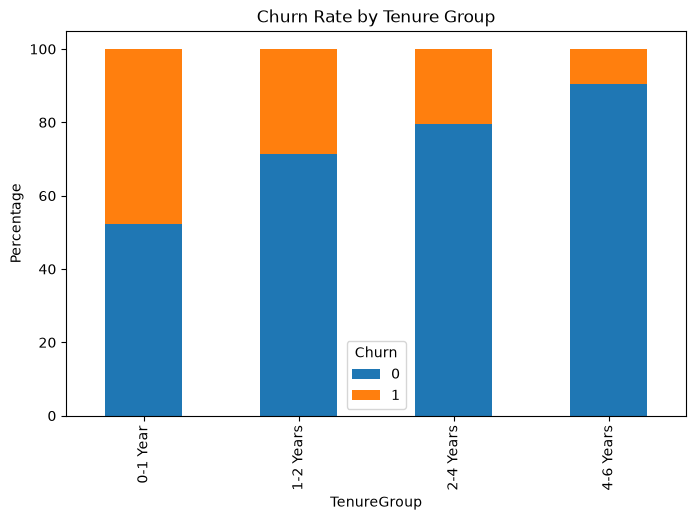

In [6]:
(
    pd.crosstab(df_fe["TenureGroup"], df_fe["Churn"], normalize="index")*100
).plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Percentage")
plt.show()

In [7]:
df_fe["AvgMonthlySpend"] = (
    df_fe["TotalCharges"] / df_fe["tenure"]
)

In [8]:
df_fe["IsNewCustomer"] = (
    df_fe["tenure"] < 12
).astype(int)

In [9]:
df_fe["LongTermContract"] = (
    df_fe["Contract"] != "Month-to-month"
).astype(int)

In [10]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_fe["TotalServices"] = (
    df_fe[service_cols] == "Yes"
).sum(axis=1)

In [11]:
df_fe["SecurityBundle"] = (
    (df_fe["OnlineSecurity"]=="Yes") &
    (df_fe["TechSupport"]=="Yes")
).astype(int)

In [12]:
df_fe["StreamingUser"] = (
    (df_fe["StreamingTV"]=="Yes") |
    (df_fe["StreamingMovies"]=="Yes")
).astype(int)

In [13]:
df_fe["AutoPayment"] = (
    df_fe["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ])
).astype(int)

In [14]:
median_charge = df_fe["MonthlyCharges"].median()

df_fe["PremiumCustomer"] = (
    df_fe["MonthlyCharges"] > median_charge
).astype(int)

In [15]:
df_fe.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Churn,TenureGroup,AvgMonthlySpend,IsNewCustomer,LongTermContract,TotalServices,SecurityBundle,StreamingUser,AutoPayment,PremiumCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,0,0-1 Year,29.850000,1,0,1,0,0,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,0,2-4 Years,55.573529,0,1,3,0,0,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,1,0-1 Year,54.075000,1,0,3,0,0,0,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,0,2-4 Years,40.905556,0,1,3,1,0,1,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,1,0-1 Year,75.825000,1,0,1,0,0,0,1


In [16]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7032 non-null   str     
 1   SeniorCitizen     7032 non-null   int64   
 2   Partner           7032 non-null   str     
 3   Dependents        7032 non-null   str     
 4   tenure            7032 non-null   int64   
 5   PhoneService      7032 non-null   str     
 6   MultipleLines     7032 non-null   str     
 7   InternetService   7032 non-null   str     
 8   OnlineSecurity    7032 non-null   str     
 9   OnlineBackup      7032 non-null   str     
 10  DeviceProtection  7032 non-null   str     
 11  TechSupport       7032 non-null   str     
 12  StreamingTV       7032 non-null   str     
 13  StreamingMovies   7032 non-null   str     
 14  Contract          7032 non-null   str     
 15  PaperlessBilling  7032 non-null   str     
 16  PaymentMethod     7032 non-null   s

In [17]:
df_fe.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer,LongTermContract,TotalServices,SecurityBundle,StreamingUser,AutoPayment,PremiumCustomer
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785,64.799424,0.292662,0.448948,3.363339,0.155859,0.497014,0.435580,0.499573
std,0.368844,24.545260,30.085974,2266.771362,0.441782,30.185891,0.455017,0.497422,2.062067,0.362747,0.500027,0.495868,0.500035
min,0.000000,1.000000,18.250000,18.800000,0.000000,13.775000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000,36.179891,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000,70.373239,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000,90.179560,1.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,121.400000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
(
    pd.crosstab(
        df_fe["IsNewCustomer"],
        df_fe["Churn"],
        normalize="index"
    )*100
)

Churn,0,1
IsNewCustomer,,
0,82.509047,17.490953
1,51.457726,48.542274


In [19]:
(
    pd.crosstab(
        df_fe["LongTermContract"],
        df_fe["Churn"],
        normalize="index"
    )*100
)

Churn,0,1
LongTermContract,,
0,57.290323,42.709677
1,93.221413,6.778587


In [20]:
(
    pd.crosstab(
        df_fe["SecurityBundle"],
        df_fe["Churn"],
        normalize="index"
    )*100
)

Churn,0,1
SecurityBundle,,
0,70.181941,29.818059
1,90.967153,9.032847


In [21]:
(
    pd.crosstab(
        df_fe["AutoPayment"],
        df_fe["Churn"],
        normalize="index"
    )*100
)

Churn,0,1
AutoPayment,,
0,65.255732,34.744268
1,84.002612,15.997388


In [22]:
(
    pd.crosstab(
        df_fe["StreamingUser"],
        df_fe["Churn"],
        normalize="index"
    )*100
)

Churn,0,1
StreamingUser,,
0,77.155782,22.844218
1,69.642346,30.357654


Encoding categorical variables temporarily

In [23]:
from sklearn.preprocessing import LabelEncoder

df_mi = df_fe.copy()

label_encoders = {}

for col in df_mi.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_mi[col] = le.fit_transform(df_mi[col].astype(str))
    label_encoders[col] = le

C:\Users\sansi\AppData\Local\Temp\ipykernel_19276\1022615494.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_mi.select_dtypes(include="object").columns:


In [24]:
df_mi["TenureGroup"] = LabelEncoder().fit_transform(
    df_mi["TenureGroup"].astype(str)
)

In [25]:
from sklearn.feature_selection import mutual_info_classif

X = df_mi.drop("Churn", axis=1)
y = df_mi["Churn"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_scores = (
    pd.Series(mi_scores, index=X.columns)
    .sort_values(ascending=False)
)

print(mi_scores)

Contract            0.102719
LongTermContract    0.084275
tenure              0.075660
OnlineSecurity      0.067185
TenureGroup         0.065167
InternetService     0.061778
TechSupport         0.058752
OnlineBackup        0.052449
MonthlyCharges      0.047039
PaymentMethod       0.045449
DeviceProtection    0.045128
IsNewCustomer       0.044719
TotalCharges        0.043429
AvgMonthlySpend     0.035409
StreamingMovies     0.030532
StreamingTV         0.026079
AutoPayment         0.021324
PaperlessBilling    0.019079
Dependents          0.016268
SecurityBundle      0.016003
PremiumCustomer     0.013919
TotalServices       0.011302
Partner             0.008461
gender              0.002990
SeniorCitizen       0.002696
MultipleLines       0.002070
PhoneService        0.001368
StreamingUser       0.000000
dtype: float64


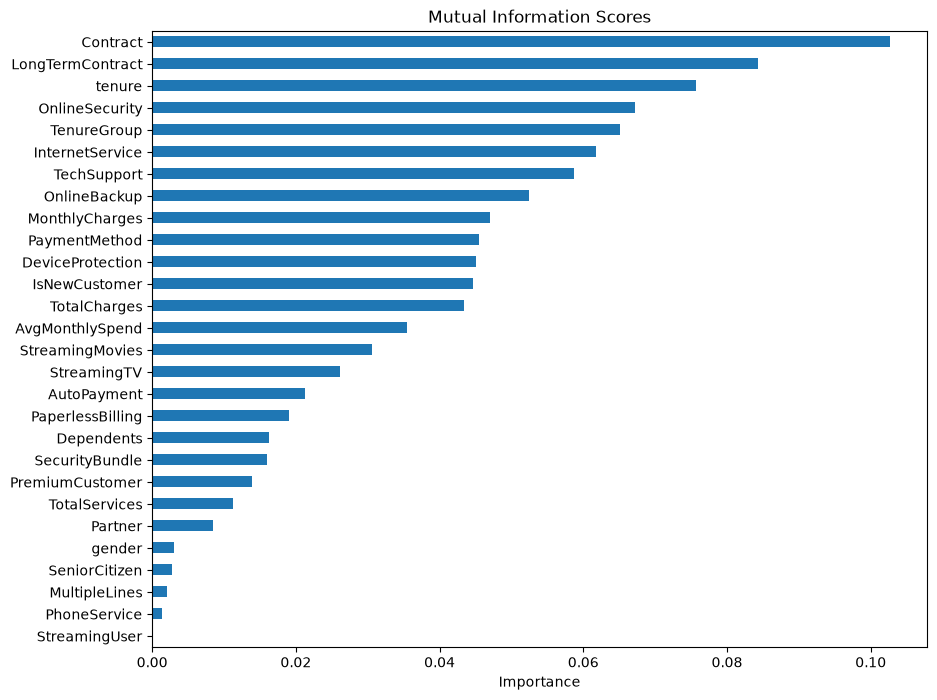

In [26]:
plt.figure(figsize=(10, 8))

mi_scores.sort_values().plot(kind="barh")

plt.title("Mutual Information Scores")
plt.xlabel("Importance")
plt.show()

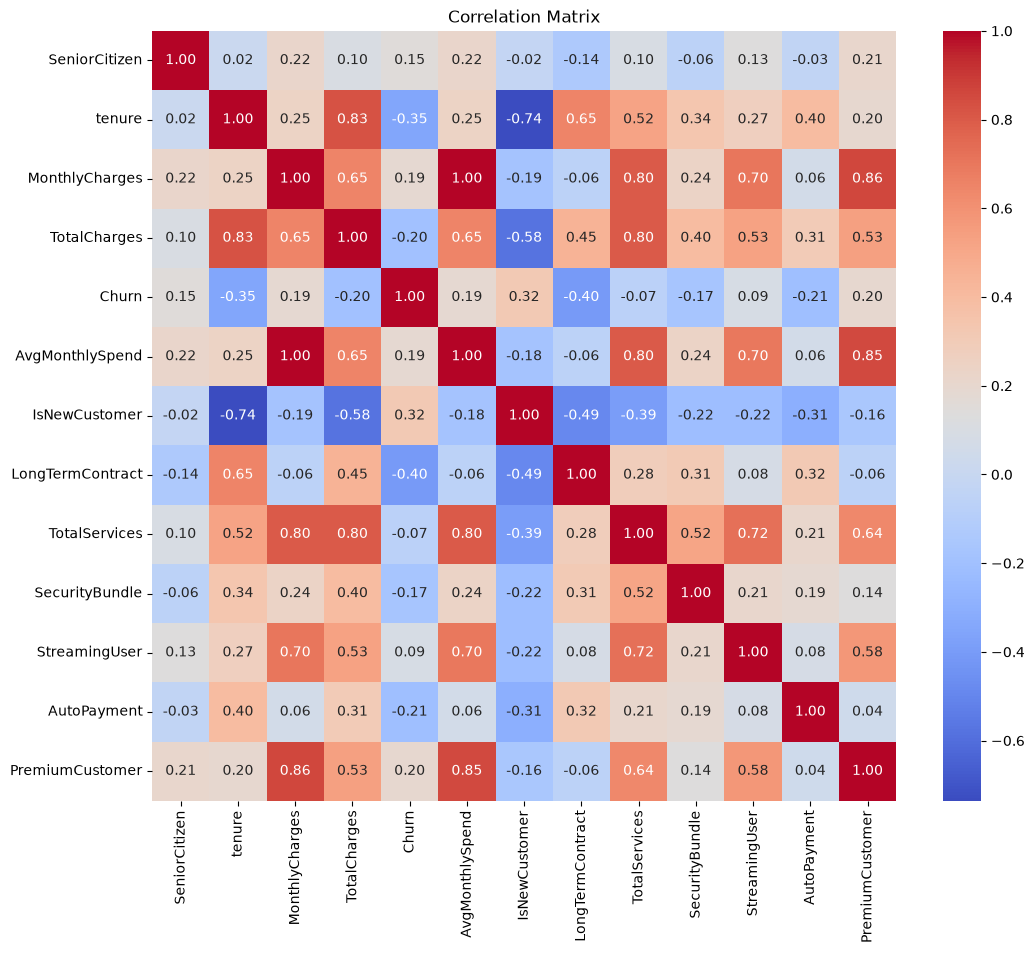

In [27]:
import seaborn as sns

numeric_cols = df_fe.select_dtypes(include=["number"]).columns

plt.figure(figsize=(12, 10))

sns.heatmap(
    df_fe[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [28]:
df_fe.to_csv("../data/processed/feature_engineered.csv", index=False)